# Atelier 1 — Statistiques descriptives & relations

## Objectif
Ce notebook accompagne **l’Atelier 1 sous Excel**.

- Excel = comprendre et manipuler les données
- Python = **vérifier**, **reproduire** et **automatiser** les mêmes calculs

⚠️ **Aucune connaissance préalable en Python n’est requise**.
Chaque cellule correspond à **une seule action**.


## Étape 0 — Charger les données

Nous chargeons le même jeu de données que dans Excel.
Le fichier doit être exporté en **CSV** depuis Excel.


In [3]:
import pandas as pd

# Charger le fichier CSV (export Excel)
df = pd.read_csv('Atelier_1_Donnees.csv')

# Afficher les premières lignes
df.head()

,Periode,Site,Mode_Operatoire,Temperature_C,Pression_bar,Charge_kNm,Vibration_mm_s,Indice_Qualite,Defauts_nb,Arret_min,NonConforme
0,4,Site_A,Mode_1,59.78,3.115,532.5,2.509,87.2,2,22.6,0
1,3,Site_C,Mode_1,61.14,3.022,579.8,2.098,90.0,2,29.9,0
2,3,Site_C,Mode_1,59.45,2.984,480.1,1.706,93.5,0,6.5,0
3,4,Site_A,Mode_3,61.63,3.207,483.4,2.353,85.7,1,52.1,0
4,3,Site_B,Mode_1,63.66,3.201,584.1,2.773,86.0,2,42.4,0


In [4]:
#df.select_dtypes(include='number')
df.describe()

,Periode,Temperature_C,Pression_bar,Charge_kNm,Vibration_mm_s,Indice_Qualite,Defauts_nb,Arret_min,NonConforme
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2.581250,62.263344,3.142375,535.665625,2.294878,87.646875,1.678125,26.303125,0.056250
std,1.127996,1.755703,0.160744,62.285745,0.313252,2.348919,1.453400,13.250561,0.230765
min,1.000000,58.010000,2.661000,377.500000,1.348000,78.400000,0.000000,3.300000,0.000000
25%,2.000000,61.010000,3.021000,491.700000,2.098000,86.275000,1.000000,16.675000,0.000000
50%,3.000000,62.220000,3.143000,531.850000,2.273000,87.650000,1.000000,24.700000,0.000000
75%,4.000000,63.377500,3.261250,576.050000,2.480500,89.125000,2.000000,32.750000,0.000000
max,4.000000,67.360000,3.606000,731.700000,3.721000,93.500000,7.000000,115.900000,1.000000


## Étape 1 — Statistiques descriptives (une variable)

Nous commençons par **Indice_Qualite**.
Objectif : comprendre le **niveau** et la **variabilité**.


In [5]:
# Moyenne
moyenne = df['Indice_Qualite'].mean()

# Médiane
mediane = df['Indice_Qualite'].median()

# Écart-type
std = df['Indice_Qualite'].std()

moyenne, mediane, std

(np.float64(87.646875), np.float64(87.65), np.float64(2.348918830195372))

In [6]:
#df_p1 = df[df["periode"] == 1]
#moyenne = df_p1["indice_qualite"].mean()

In [7]:
import pandas as pd
import numpy as np

# Groupement par période
groupes = df.groupby("Periode")["Indice_Qualite"]

# Calcul des statistiques
stats_par_periode = pd.DataFrame({
    "Moyenne": groupes.mean(),
    "Médiane": groupes.median(),
    "Variance": groupes.var(),
    "Écart-type": groupes.std(),
    "Min": groupes.min(),
    "Max": groupes.max(),
    "Q1": groupes.quantile(0.25),
    "Q3": groupes.quantile(0.75)
})

# IQR = Q3 - Q1
stats_par_periode["IQR"] = stats_par_periode["Q3"] - stats_par_periode["Q1"]

# Coefficient de variation
stats_par_periode["CV"] = stats_par_periode["Écart-type"] / stats_par_periode["Moyenne"]

stats_par_periode


,Moyenne,Médiane,Variance,Écart-type,Min,Max,Q1,Q3,IQR,CV
Periode,,,,,,,,,,
1,87.108000,87.1,5.702097,2.387906,82.1,92.4,85.5,88.75,3.25,0.027413
2,87.473973,87.7,6.164730,2.482887,78.4,93.1,86.2,88.90,2.70,0.028384
3,87.778313,87.9,4.608548,2.146753,82.0,93.5,86.6,89.20,2.60,0.024457
4,88.120225,88.1,5.352314,2.313507,81.5,93.1,86.8,89.40,2.60,0.026254


In [10]:
groupes 
groupes.head()

0     87.2
1     90.0
2     93.5
3     85.7
4     86.0
5     86.7
6     87.4
7     86.9
8     88.7
9     88.1
10    88.4
11    85.3
13    84.7
14    87.1
16    91.1
18    82.8
19    90.3
21    88.9
24    87.3
29    87.9
Name: Indice_Qualite, dtype: float64

➡️ **Lecture** :
- moyenne = niveau central
- médiane = valeur typique robuste
- écart-type = dispersion


## Étape 2 — Histogramme

L’histogramme permet de **voir la forme** de la distribution.


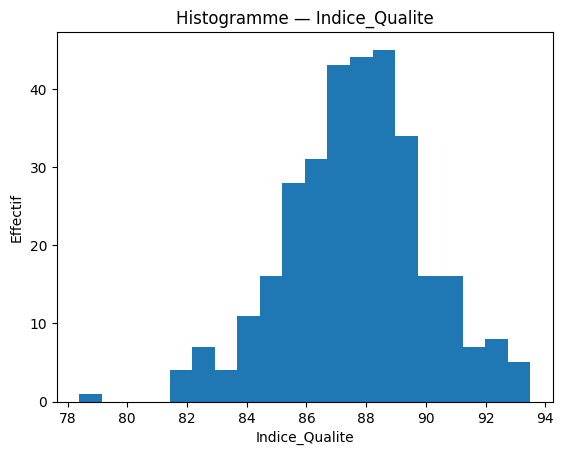

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['Indice_Qualite'], bins=20)
plt.title('Histogramme — Indice_Qualite')
plt.xlabel('Indice_Qualite')
plt.ylabel('Effectif')
plt.show()

➡️ **Questions à se poser** :
- Distribution symétrique ?
- Valeurs atypiques ?


## Étape 3 — Boxplot par groupe

Comparer **Indice_Qualite** entre périodes.


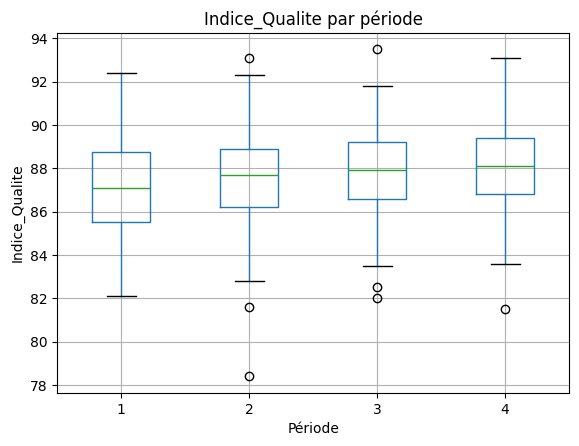

In [6]:
df.boxplot(column='Indice_Qualite', by='Periode')
plt.title('Indice_Qualite par période')
plt.suptitle('')
plt.xlabel('Période')
plt.ylabel('Indice_Qualite')
plt.show()

➡️ **Lecture** :
- médiane par période
- dispersion
- outliers


## Étape 4 — Relation entre deux variables

Nous étudions la relation entre :
- **Vibration_mm_s**
- **Indice_Qualite**


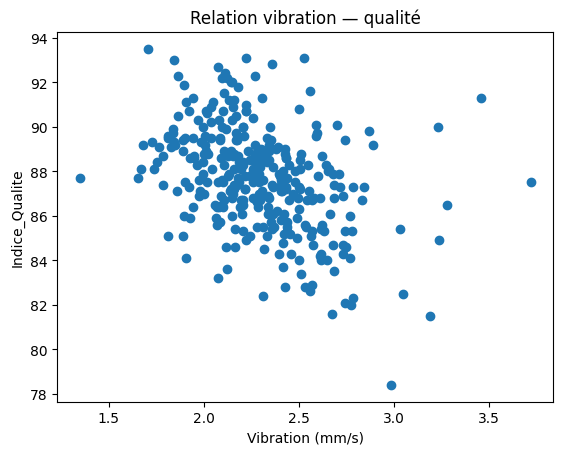

In [7]:
plt.scatter(df['Vibration_mm_s'], df['Indice_Qualite'])
plt.xlabel('Vibration (mm/s)')
plt.ylabel('Indice_Qualite')
plt.title('Relation vibration — qualité')
plt.show()

➡️ Le nuage de points montre une **tendance** possible.





### Etape 4.1 Covariance et Corrélation entre les deux variables Indice Qualité et Vibration

In [ ]:

# 1. Corrélation de Pearson
correlation = df['Vibration_mm_s'].corr(df['Indice_Qualite'])

# 2. Covariance
covariance = df[['Vibration_mm_s', 'Indice_Qualite']].cov().iloc[0, 1]
#sans iloc, cov est une matrice 2*2 

# 3. Affichage des résultats
print("Coefficient de corrélation :", correlation)
print("Covariance :", covariance)


Coefficient de corrélation : -0.38273506244331046
Covariance : -0.281617780172414


### Etape 4.2 Régression linéaire entre Indice Qualité (Y) et Vibration (X)

### Objectif

Modéliser 
$$Indice_Qualite=a×Vibration_mm_s+b$$
et affichier 
* l’équation de la droite
* le coefficient de détermination R2R^2R2

### Step 1 — Import et préparation des données

In [28]:
from sklearn.linear_model import LinearRegression

# Variables explicative (X) et cible (y)
X = df[['Vibration_mm_s']]      # X doit être en DataFrame (2D)
y = df['Indice_Qualite']        # y peut être une Series (1D)


### Step 2 - Régression linéaire

In [29]:
# Création du modèle
model = LinearRegression()

# Apprentissage du modèle
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


###  Step 3 — Résultats : équation et R²

In [34]:
# Coefficients
a = model.coef_[0]      # pente
b = model.intercept_    # origine à l'origine

# Coefficient de détermination R²
r2 = model.score(X, y)
# Affichage
print("Indice_Qualite =", a, "* Vibration_mm_s +", b)

print("Coefficient de détermination R² :")
print("R² =", r2)


Indice_Qualite = -2.8699375578064763 * Vibration_mm_s + 94.23303192152599
Coefficient de détermination R² :
R² = 0.14648612802348449


## Étape 5 — Matrice de Corrélation pour toutes les variables



In [17]:
df.columns

Index(['Periode', 'Site', 'Mode_Operatoire', 'Temperature_C', 'Pression_bar',
       'Charge_kNm', 'Vibration_mm_s', 'Indice_Qualite', 'Defauts_nb',
       'Arret_min', 'NonConforme'],
      dtype='str')

In [ ]:

#Matrice de corrélation de Pearson pour toutes les variables numériques
df_num = df[['Temperature_C', 'Pression_bar', 'Charge_kNm', 'Vibration_mm_s', 'Indice_Qualite', 'Arret_min']]
#Another way : df_num = df.select_dtypes(include='number')
Correlation_Matrix = df_num.corr()
Correlation_Matrix

,Temperature_C,Pression_bar,Charge_kNm,Vibration_mm_s,Indice_Qualite,Arret_min
Temperature_C,1.000000,0.416348,0.713660,0.476214,-0.182612,0.103051
Pression_bar,0.416348,1.000000,0.551965,0.579649,-0.243779,0.129134
Charge_kNm,0.713660,0.551965,1.000000,0.618953,-0.284005,0.055342
Vibration_mm_s,0.476214,0.579649,0.618953,1.000000,-0.382735,0.193395
Indice_Qualite,-0.182612,-0.243779,-0.284005,-0.382735,1.000000,0.003219
Arret_min,0.103051,0.129134,0.055342,0.193395,0.003219,1.000000


➡️ **Rappel important** :
- Corrélation ≠ causalité
- Toujours interpréter avec un graphique


## Synthèse de l’atelier 1

Vous avez appris à :
- décrire une variable
- visualiser une distribution
- comparer des groupes
- explorer une relation entre deux variables

👉 Ces étapes sont **indispensables avant de faire des tests statistiques** (Atelier 2).
